# EDA — Base analítica completa (`base_analitica`)

**Escopo deste notebook:** análise exploratória de **toda** a `base_analitica`
— o resultado final do pipeline Medallion, com os microdados de aluno da
Avaliação de Alfabetização (INEP) enriquecidos com contexto municipal/estadual
das cinco fontes do projeto. Complementa os EDAs por fonte
(`2.0-eda-atlas-fundeb.ipynb` e os dos demais responsáveis), olhando a base
como ela chega para a modelagem.

**Grão:** 1 linha por aluno-ano (`id_aluno` × `ano`). As colunas `ctx_*` são
atributos do **município** (ou UF) do aluno, repetidos para todos os alunos do
mesmo ente — isso é levado em conta nas análises abaixo.

**Famílias de colunas (prefixo → fonte):**

| Prefixo | Fonte | Conteúdo |
| --- | --- | --- |
| *(sem prefixo)* | INEP microdados | chaves + `dependencia_administrativa` + `label_alfabetizado` (alvo) |
| `ctx_atu_*` | Censo Escolar | razão aluno/turma por etapa de ensino |
| `ctx_atlas_*` | Atlas do Desenvolvimento Humano | 35 indicadores socioeconômicos (ano-base 2010) |
| `ctx_fundeb_*` | INEP / FUNDEB | Nível Socioeconômico (NSE) do ente federado |
| `ctx_ibge_*` | IBGE | população, área, saneamento, renda domiciliar |
| `ctx_inep_*` | INEP Gold (município/UF) | taxa/média/meta de alfabetização **defasadas 1 ano** (`_lag1`) |

**Cuidados de leitura assumidos no notebook:**
- `ctx_inep_*_lag1` são defasadas de propósito (`join.py` / `roles.py`) — a
  edição do ano corrente seria vazamento. `_meta` não é defasada (o INEP
  publica antes da prova).
- `proficiencia` / `gap_proficiencia` **não entram** na base (marcadas como
  vazamento em `roles.py`) — confirmado na seção 2.
- Atlas fixo em 2010: vale como contexto estrutural, não como medida
  contemporânea.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def heatmap(data, ax, cmap="coolwarm", center=None, vmin=None, vmax=None,
            annot=False, fmt=".2f", cbar_label=None, xticklabels=None, yticklabels=None):
    # Substituto enxuto de sns.heatmap, so com matplotlib.
    arr = np.asarray(data, dtype=float)
    if center is not None:
        lim = np.nanmax(np.abs(arr - center))
        vmin, vmax = center - lim, center + lim
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    xt = xticklabels if xticklabels is not None else list(getattr(data, "columns", range(arr.shape[1])))
    yt = yticklabels if yticklabels is not None else list(getattr(data, "index", range(arr.shape[0])))
    ax.set_xticks(range(arr.shape[1]))
    ax.set_xticklabels(xt, rotation=90, fontsize=7)
    ax.set_yticks(range(arr.shape[0]))
    ax.set_yticklabels(yt, fontsize=7)
    if annot:
        for i in range(arr.shape[0]):
            for j in range(arr.shape[1]):
                v = arr[i, j]
                if np.isfinite(v):
                    ax.text(j, i, format(v, fmt), ha="center", va="center", fontsize=7,
                            color="white" if abs(v - (center or 0)) > 0.5 * (vmax or 1) else "black")
    cb = ax.figure.colorbar(im, ax=ax, shrink=0.6)
    if cbar_label:
        cb.set_label(cbar_label)
    return im

## 1. Carregando a base

In [2]:
DEST = Path("../data/processed/base_analitica")

partes = sorted(DEST.glob("ano=*"))
dfs = []
for p in partes:
    ano = int(p.name.split("=")[1])
    sub = pd.read_parquet(p)
    sub["ano"] = ano
    dfs.append(sub)

df = pd.concat(dfs, ignore_index=True)
print(f"{len(df):,} linhas x {len(df.columns)} colunas")
print("Anos:", sorted(df["ano"].unique()))
print("Memória:", f"{df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

5,320,732 linhas x 84 colunas
Anos: [np.int64(2023), np.int64(2024), np.int64(2025)]
Memória: 3.76 GB


In [3]:
# Mapa de famílias de colunas
CHAVES = ["ano", "id_uf", "id_municipio", "id_escola", "id_aluno"]
ALVO = "label_alfabetizado"
META_COLS = ["dependencia_administrativa", "_gold_processed_at"]

FAMILIAS = {
    "atu": [c for c in df.columns if c.startswith("ctx_atu_")],
    "atlas": [c for c in df.columns if c.startswith("ctx_atlas_")],
    "fundeb": [c for c in df.columns if c.startswith("ctx_fundeb_")],
    "ibge": [c for c in df.columns if c.startswith("ctx_ibge_")],
    "inep": [c for c in df.columns if c.startswith("ctx_inep_")],
}
CTX_COLS = [c for fam in FAMILIAS.values() for c in fam]

for nome, cols in FAMILIAS.items():
    print(f"{nome:8s} {len(cols):3d} colunas")
print(f"{'TOTAL ctx':8s} {len(CTX_COLS):3d}")
print(f"\nnão-ctx: {[c for c in df.columns if c not in CTX_COLS]}")

atu       22 colunas
atlas     35 colunas
fundeb     4 colunas
ibge       6 colunas
inep       9 colunas
TOTAL ctx  76

não-ctx: ['ano', 'id_uf', 'id_municipio', 'id_escola', 'id_aluno', 'dependencia_administrativa', 'label_alfabetizado', '_gold_processed_at']


## 2. Panorama e integridade do grão

Antes de qualquer distribuição: a base tem o grão que esperamos? As chaves são
consistentes? Sobrou alguma coluna de vazamento?

In [4]:
# Grão: 1 linha por aluno-ano?
dup = df.duplicated(subset=["id_aluno", "ano"]).sum()
print(f"Linhas duplicadas em (id_aluno, ano): {dup}")

print(f"\nid_aluno distintos: {df['id_aluno'].nunique():,}")
print(f"Total de linhas:    {len(df):,}")
alunos_multi_ano = (df.groupby("id_aluno")["ano"].nunique() > 1).sum()
print(f"Alunos em mais de um ano: {alunos_multi_ano:,} "
      f"({alunos_multi_ano / df['id_aluno'].nunique():.1%})")

print("\nContagens por ano:")
resumo_ano = df.groupby("ano").agg(
    alunos=("id_aluno", "nunique"),
    escolas=("id_escola", "nunique"),
    municipios=("id_municipio", "nunique"),
    ufs=("id_uf", "nunique"),
)
print(resumo_ano)

Linhas duplicadas em (id_aluno, ano): 0



id_aluno distintos: 2,826,311
Total de linhas:    5,320,732


Alunos em mais de um ano: 1,793,730 (63.5%)

Contagens por ano:


       alunos  escolas  municipios  ufs
ano                                    
2023  1502809    36525        4871   23
2024  1851828    42327        5517   26
2025  1966095    43538        5556   27


In [5]:
# Checagem de vazamento: nada de proficiencia / gap / caderno na base
suspeitas = [c for c in df.columns
             if any(t in c.lower() for t in ("profic", "gap", "caderno", "acerto", "nota"))]
print("Colunas suspeitas de vazamento encontradas:", suspeitas or "NENHUMA (ok)")

# _lag1 explícito nas colunas de resultado do INEP
lag_cols = [c for c in FAMILIAS["inep"] if c.endswith("_lag1")]
meta_cols_inep = [c for c in FAMILIAS["inep"] if c.endswith("_meta")]
print(f"\nINEP defasadas (_lag1): {lag_cols}")
print(f"INEP não-defasadas (meta, ok publicar): {meta_cols_inep}")

Colunas suspeitas de vazamento encontradas: NENHUMA (ok)

INEP defasadas (_lag1): ['ctx_inep_mun_taxa_alfabetizacao_lag1', 'ctx_inep_mun_media_portugues_lag1', 'ctx_inep_mun_percentual_participacao_lag1', 'ctx_inep_mun_nivel_alfabetizacao_lag1', 'ctx_inep_uf_taxa_alfabetizacao_lag1', 'ctx_inep_uf_media_portugues_lag1', 'ctx_inep_uf_percentual_participacao_lag1']
INEP não-defasadas (meta, ok publicar): ['ctx_inep_mun_meta', 'ctx_inep_uf_meta']


In [6]:
# Tipos de dado e cardinalidade — visão compacta
perfil = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulos_%": (df.isna().mean() * 100).round(2),
    "nunique": df.nunique(),
})
perfil["familia"] = [
    next((f for f, cols in FAMILIAS.items() if c in cols), "chave/alvo")
    for c in perfil.index
]
perfil

,dtype,nulos_%,nunique,familia
ano,int64,0.00,3,chave/alvo
id_uf,Int64,0.00,27,chave/alvo
id_municipio,string,0.00,5567,chave/alvo
id_escola,string,0.00,43644,chave/alvo
id_aluno,string,0.00,2826311,chave/alvo
...,...,...,...,...
ctx_inep_mun_meta,float64,29.22,105,inep
ctx_inep_uf_taxa_alfabetizacao_lag1,float64,29.47,49,inep
ctx_inep_uf_media_portugues_lag1,float64,29.47,49,inep
ctx_inep_uf_percentual_participacao_lag1,float64,29.47,49,inep


## 3. O alvo — `label_alfabetizado`

Binário: 1 = aluno alfabetizado, 0 = não. É o que o projeto quer prever.
Olhamos o balanço geral, a evolução por ano e por rede de ensino.

In [7]:
taxa_geral = df[ALVO].mean()
print(f"Taxa de alfabetização (base inteira): {taxa_geral:.3%}")
print(f"Positivos: {df[ALVO].sum():,}  |  Negativos: {(df[ALVO] == 0).sum():,}")
print(f"Nulos no alvo: {df[ALVO].isna().sum()}")

por_ano = df.groupby("ano")[ALVO].agg(["mean", "count"])
por_ano.columns = ["taxa_alfabetizado", "n_alunos"]
print()
print(por_ano)

Taxa de alfabetização (base inteira): 61.781%
Positivos: 3,287,215  |  Negativos: 2,033,517
Nulos no alvo: 0

      taxa_alfabetizado  n_alunos
ano                              
2023           0.583858   1502809
2024           0.597843   1851828
2025           0.662575   1966095


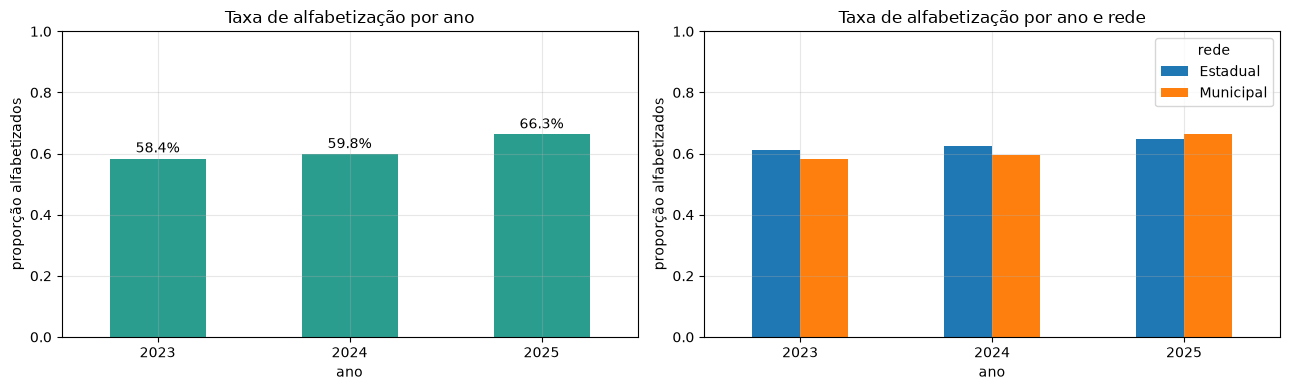

               mean    count
rede                        
Estadual   0.631226   615794
Municipal  0.616057  4704938


In [8]:
# INEP: 2=Estadual, 3=Municipal (na base só aparecem essas duas redes)
DEP_ADM = {1: "Federal", 2: "Estadual", 3: "Municipal", 4: "Privada"}
df["rede"] = df["dependencia_administrativa"].map(DEP_ADM)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

por_ano["taxa_alfabetizado"].plot(kind="bar", ax=axes[0], color="#2a9d8f", rot=0)
axes[0].set_title("Taxa de alfabetização por ano")
axes[0].set_ylabel("proporção alfabetizados")
axes[0].set_ylim(0, 1)
for i, v in enumerate(por_ano["taxa_alfabetizado"]):
    axes[0].text(i, v + 0.02, f"{v:.1%}", ha="center")

tab = df.pivot_table(index="ano", columns="rede", values=ALVO, aggfunc="mean")
tab.plot(kind="bar", ax=axes[1], rot=0)
axes[1].set_title("Taxa de alfabetização por ano e rede")
axes[1].set_ylabel("proporção alfabetizados")
axes[1].set_ylim(0, 1)
axes[1].legend(title="rede")

plt.tight_layout()
plt.show()

print(df.groupby("rede")[ALVO].agg(["mean", "count"]))

## 4. Valores faltantes

Cada família tem um padrão esperado de ausência — a maior parte é decisão de
design, não falha de join. Confrontamos o observado com a expectativa:

- **`ctx_atlas_*`** → 0% em todo ano (2010 replicado; 6 municípios criados
  pós-Censo 2010 são a única ausência de origem, ~0,04%).
- **`ctx_fundeb_*`** → alto em 2023 (o NSE só é publicado a partir de 2024,
  sem proxy — ver `join.py`).
- **`ctx_ibge_populacao_residente`** → ausente em 2023 (fonte não cobre o ano).
- **`ctx_inep_*_lag1`** → ausente onde não há edição anterior da avaliação
  para aquele município/UF (defasagem de 1 ano; 2023 puxa de 2022, que tem
  cobertura menor).
- **`ctx_atu_medio_*`** → alto em toda a base: alfabetização é 2º ano do
  fundamental; escolas só de ensino médio não têm alunos aqui, então a razão
  aluno/turma do médio fica indefinida para a maioria.

In [9]:
nulos_familia_ano = {}
for fam, cols in FAMILIAS.items():
    nulos_familia_ano[fam] = df.groupby("ano")[cols].apply(lambda g: g.isna().mean().mean() * 100)
nulos_familia_ano = pd.DataFrame(nulos_familia_ano).round(1)
print("% médio de nulos por família e ano:")
print(nulos_familia_ano)

% médio de nulos por família e ano:
       atu  atlas  fundeb  ibge   inep
ano                                   
2023  30.5    0.0   100.0  16.7  100.0
2024  30.2    0.0     0.6   0.0    2.1
2025  30.5    0.0     0.6   0.0    2.1


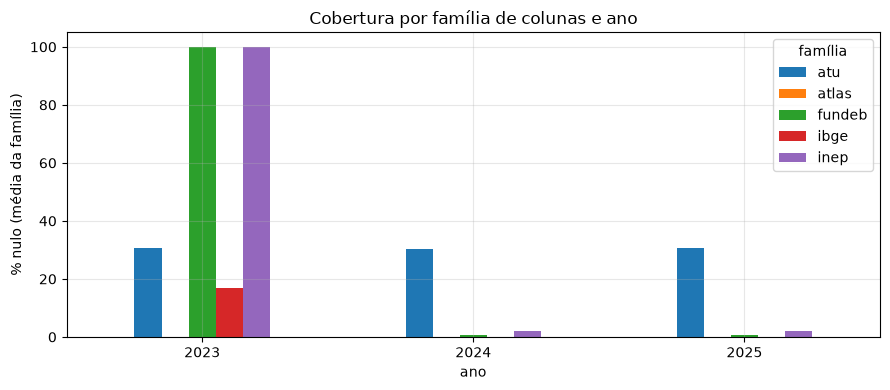

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
nulos_familia_ano.plot(kind="bar", ax=ax, rot=0)
ax.set_ylabel("% nulo (média da família)")
ax.set_title("Cobertura por família de colunas e ano")
ax.legend(title="família")
plt.tight_layout()
plt.show()

In [11]:
# Detalhe por coluna: só as que têm algum nulo, ordenadas
nulos_col = (df[CTX_COLS].isna().mean() * 100).round(2)
nulos_col = nulos_col[nulos_col > 0].sort_values(ascending=False)
print(f"{len(nulos_col)} colunas ctx com algum nulo (de {len(CTX_COLS)}):\n")
print(nulos_col.to_string())

69 colunas ctx com algum nulo (de 76):

ctx_atu_medio_nao_seriado                                96.00
ctx_atu_medio_4_serie                                    95.89
ctx_atu_medio_1_serie                                    83.38
ctx_atu_medio_2_serie                                    83.37
ctx_atu_medio_3_serie                                    83.34
ctx_atu_medio                                            83.19
ctx_atu_multietapa                                       34.97
ctx_inep_mun_nivel_alfabetizacao_lag1                    30.95
ctx_inep_mun_percentual_participacao_lag1                30.95
ctx_inep_mun_taxa_alfabetizacao_lag1                     29.73
ctx_inep_mun_media_portugues_lag1                        29.73
ctx_inep_uf_media_portugues_lag1                         29.47
ctx_inep_uf_percentual_participacao_lag1                 29.47
ctx_inep_uf_taxa_alfabetizacao_lag1                      29.47
ctx_inep_mun_meta                                        29.22
ctx_fundeb_pond

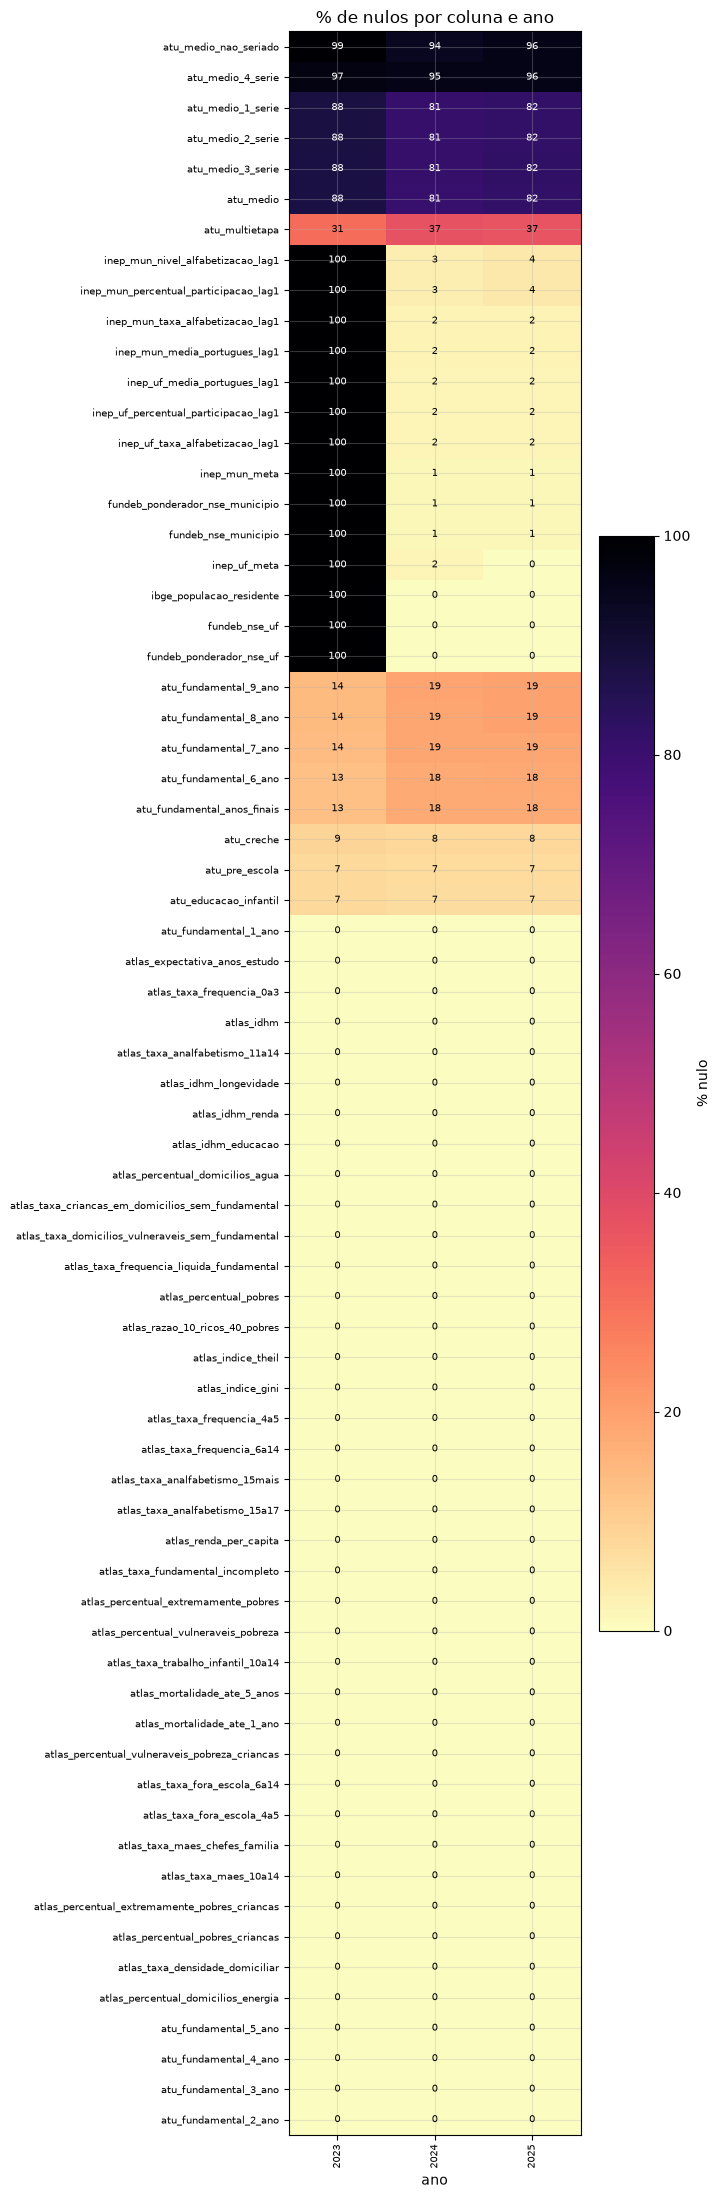

In [12]:
# Heatmap nulos: coluna x ano (só colunas com nulos)
piv = df.groupby("ano")[nulos_col.index.tolist()].apply(lambda g: g.isna().mean() * 100).T

fig, ax = plt.subplots(figsize=(7, max(4, len(piv) * 0.32)))
heatmap(piv, ax=ax, annot=True, fmt=".0f", cmap="magma_r", vmin=0, vmax=100,
        cbar_label="% nulo",
        xticklabels=list(piv.columns),
        yticklabels=[c.split("ctx_")[-1] for c in piv.index])
ax.set_title("% de nulos por coluna e ano")
ax.set_xlabel("ano")
plt.tight_layout()
plt.show()

## 5. Distribuições — nível município

As colunas `ctx_*` descrevem o município, não o aluno. Se a gente histograma
direto na base, cada município entra ponderado pelo nº de alunos — o que
distorce a forma da distribuição (municípios grandes dominam). Aqui reduzimos a
**um registro por município-ano** para ver a distribuição real dos indicadores.

In [13]:
# Base município-ano (contexto é constante dentro de município-ano)
mun_cols = [c for c in CTX_COLS if not c.startswith("ctx_inep_uf") and c != "ctx_inep_uf_meta"]
mun = (
    df.drop_duplicates(subset=["id_municipio", "ano"])
      .set_index(["id_municipio", "ano"])[CTX_COLS + ["id_uf"]]
      .copy()
)
print(f"{len(mun):,} municípios-ano  ({mun.index.get_level_values(0).nunique():,} municípios distintos)")

15,944 municípios-ano  (5,567 municípios distintos)


In [14]:
def grade_hist(cols, titulo, ncols=4, base=mun):
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.4, nrows * 2.6))
    axes = np.atleast_1d(axes).flatten()
    for ax, c in zip(axes, cols):
        s = base[c].dropna()
        ax.hist(s, bins=30, edgecolor="white", color="#4c72b0")
        nome = c.split("ctx_")[-1]
        ax.set_title(nome, fontsize=8)
        ax.tick_params(labelsize=7)
    for ax in axes[n:]:
        ax.set_visible(False)
    fig.suptitle(titulo, fontsize=12, y=1.002)
    plt.tight_layout()
    plt.show()

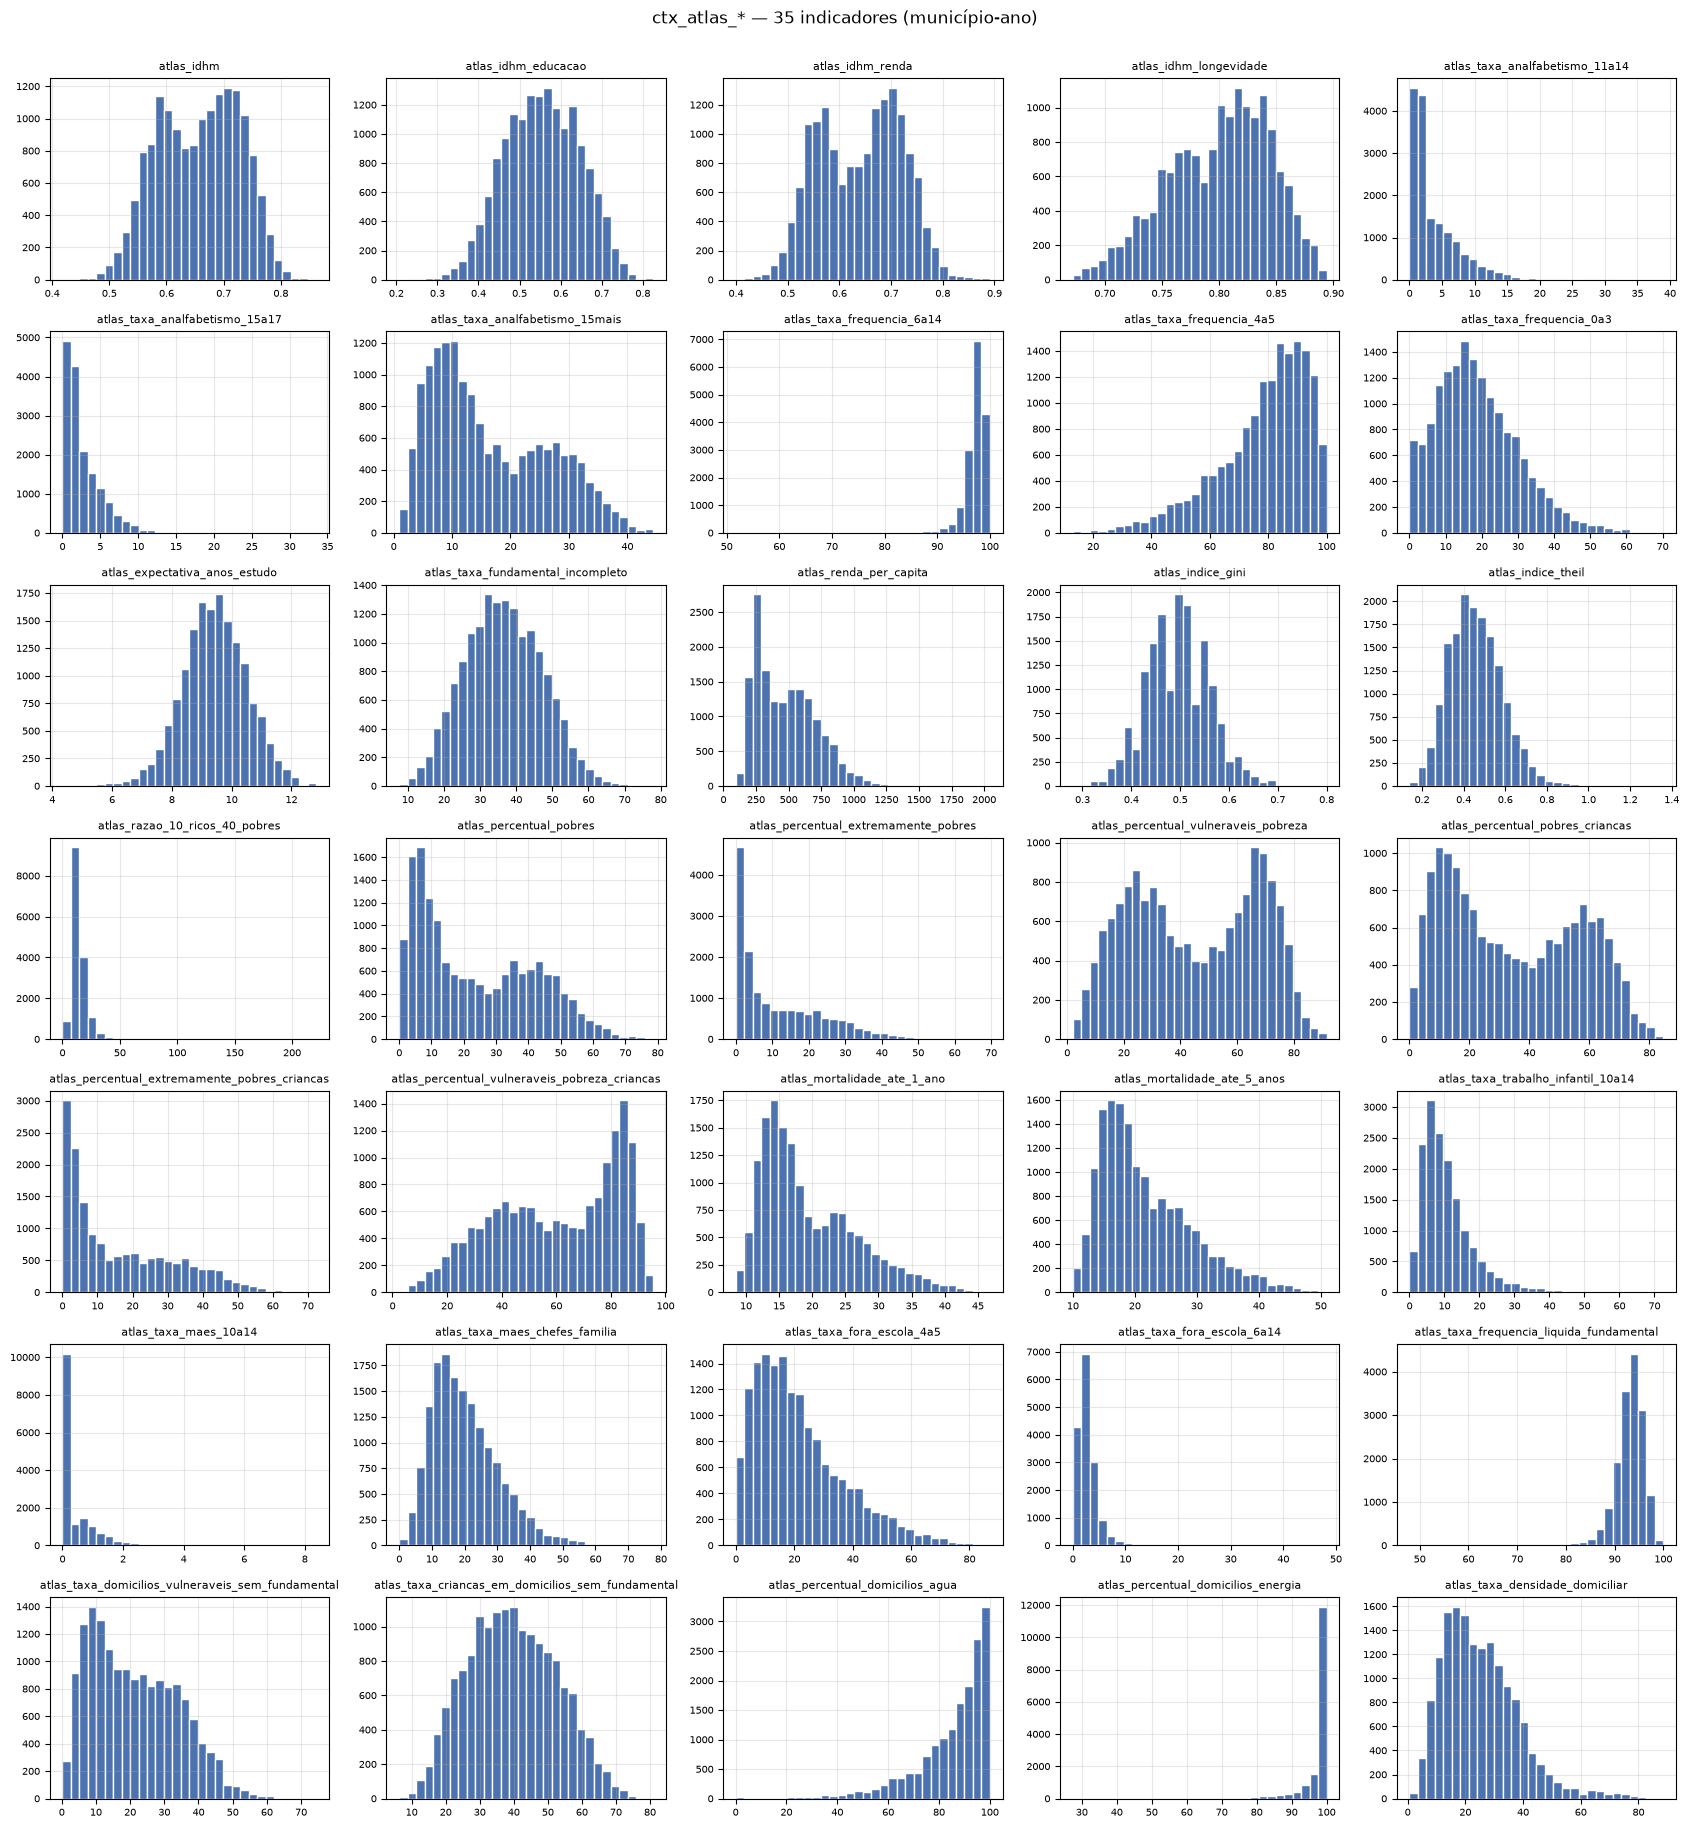

In [15]:
grade_hist(FAMILIAS["atlas"], "ctx_atlas_* — 35 indicadores (município-ano)", ncols=5)

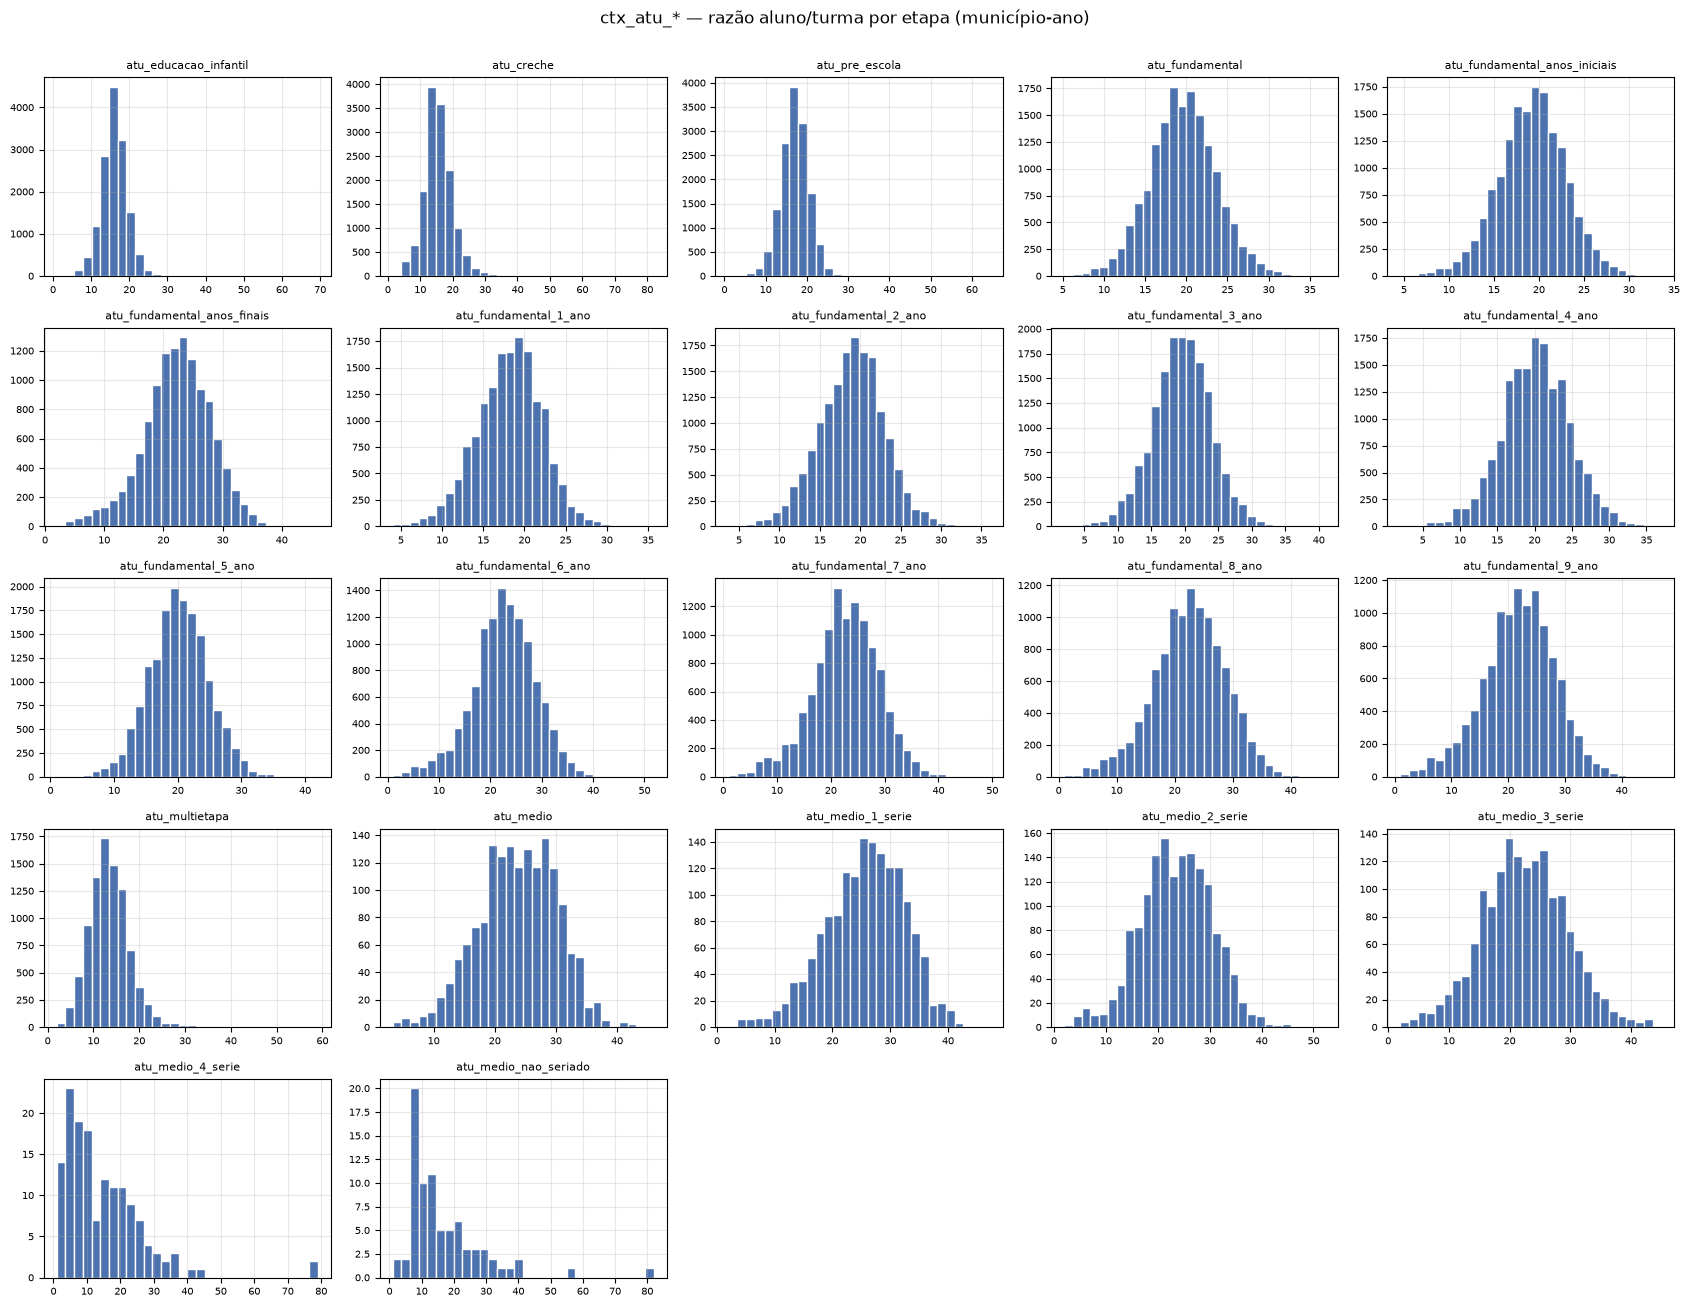

In [16]:
grade_hist(FAMILIAS["atu"], "ctx_atu_* — razão aluno/turma por etapa (município-ano)", ncols=5)

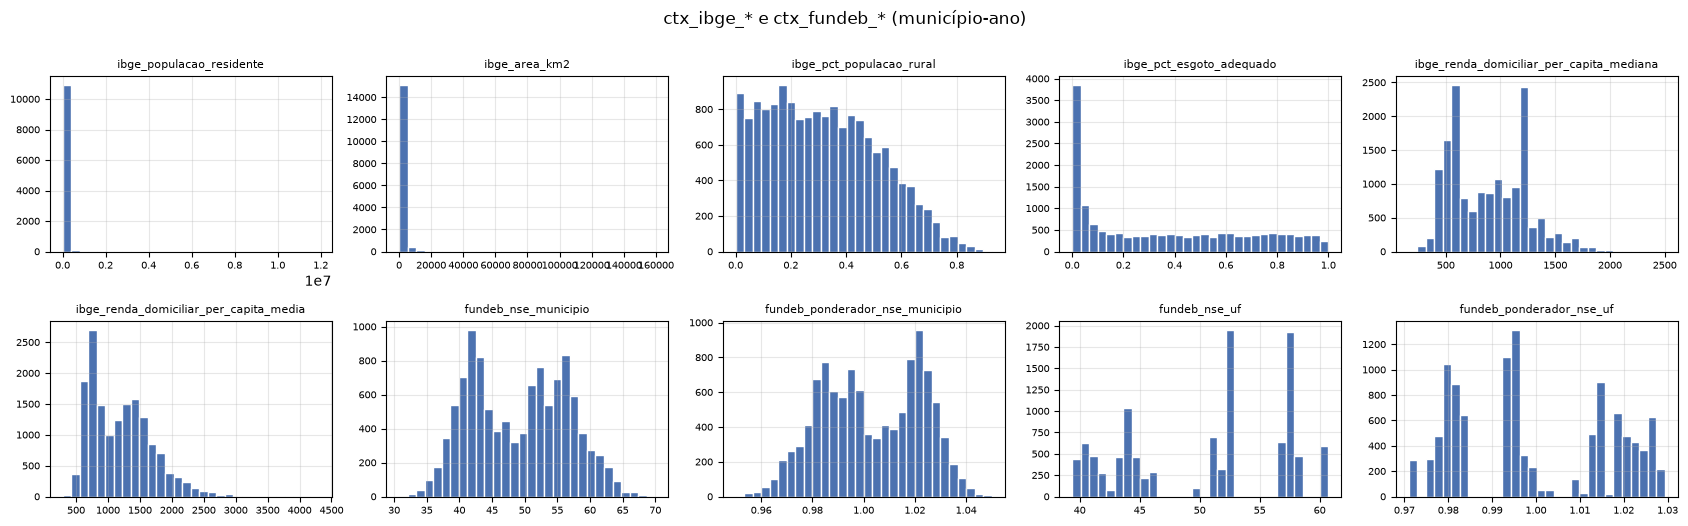

In [17]:
grade_hist(FAMILIAS["ibge"] + FAMILIAS["fundeb"], "ctx_ibge_* e ctx_fundeb_* (município-ano)", ncols=5)

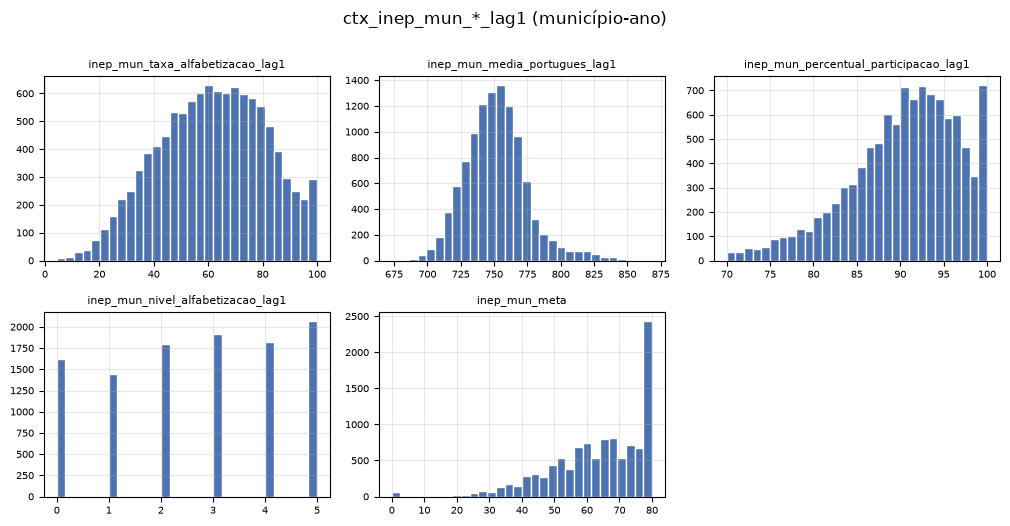

In [18]:
grade_hist([c for c in FAMILIAS["inep"] if c.startswith("ctx_inep_mun")],
           "ctx_inep_mun_*_lag1 (município-ano)", ncols=3)

In [19]:
# Estatísticas descritivas por família (nível município-ano)
for fam in ["atlas", "atu", "ibge", "fundeb", "inep"]:
    print(f"\n===== {fam} =====")
    print(mun[FAMILIAS[fam]].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(2))


===== atlas =====
                                                      mean     std    min     25%     50%     75%      max
ctx_atlas_idhm                                        0.66    0.07   0.42    0.60    0.66    0.71     0.86
ctx_atlas_idhm_educacao                               0.55    0.09   0.21    0.49    0.56    0.62     0.82
ctx_atlas_idhm_renda                                  0.64    0.08   0.40    0.57    0.65    0.70     0.89
ctx_atlas_idhm_longevidade                            0.80    0.04   0.67    0.77    0.81    0.84     0.89
ctx_atlas_taxa_analfabetismo_11a14                    3.77    3.79   0.00    1.20    2.10    5.42    38.98
ctx_atlas_taxa_analfabetismo_15a17                    2.71    2.56   0.00    0.97    1.78    3.84    33.53
ctx_atlas_taxa_analfabetismo_15mais                  16.51    9.87   0.95    8.33   13.66   24.74    44.40
ctx_atlas_taxa_frequencia_6a14                       97.13    2.56  51.77   96.54   97.60   98.46   100.00
ctx_atlas_taxa_fre

## 6. Correlação

Duas visões:
1. **Dentro de cada família** — para achar redundância (indicadores quase
   colineares, candidatos a poda antes da modelagem).
2. **Entre famílias** — as fontes trazem sinal complementar ou medem a mesma
   coisa por caminhos diferentes?

Tudo em nível município-ano, correlação de Spearman (indicadores têm caudas e
relações monotônicas não-lineares).

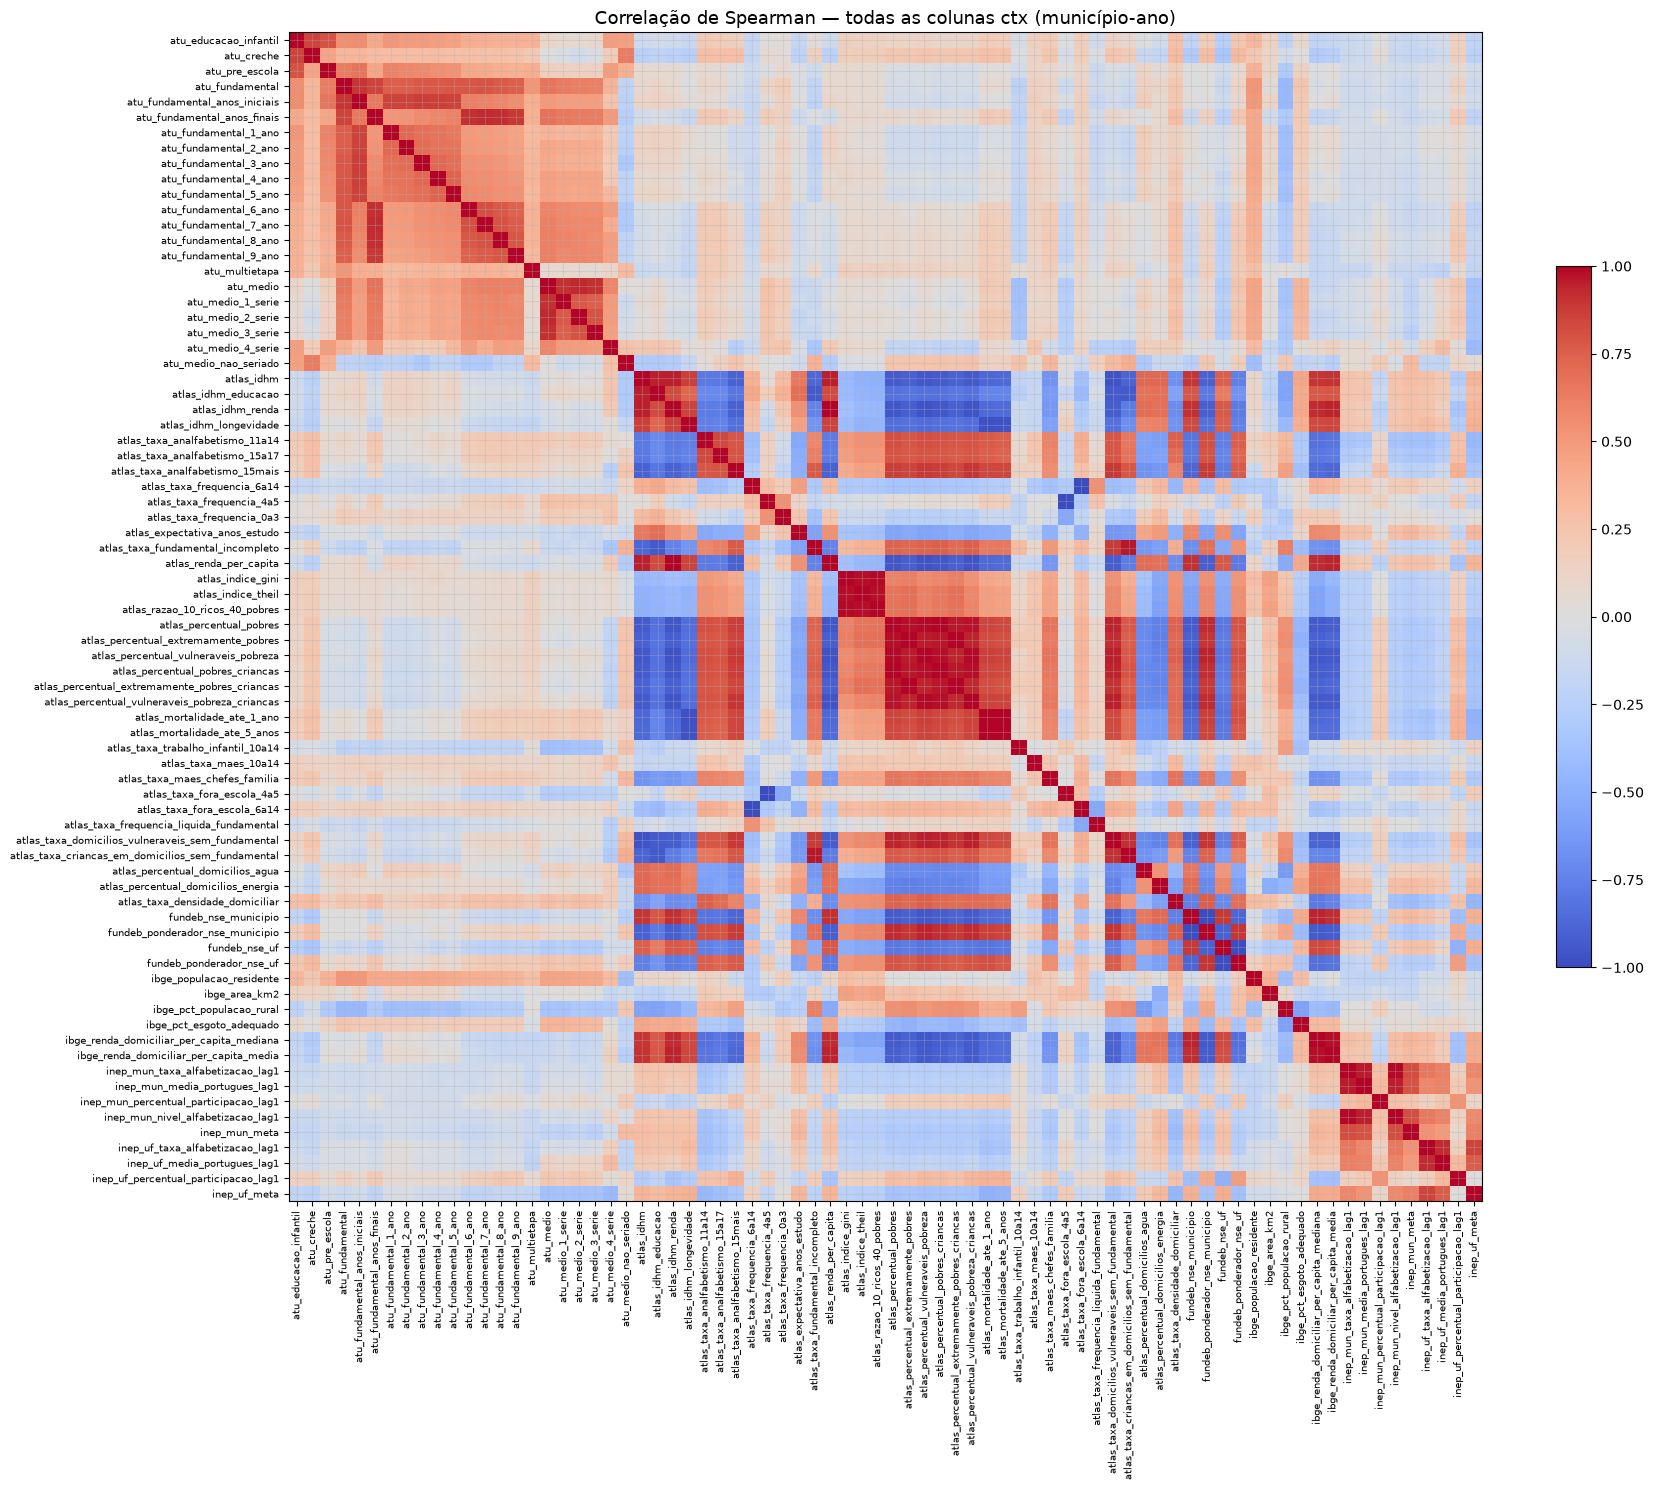

In [20]:
corr = mun[CTX_COLS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(18, 15))
heatmap(corr, ax=ax, cmap="coolwarm", center=0,
        xticklabels=[c.split("ctx_")[-1] for c in corr.columns],
        yticklabels=[c.split("ctx_")[-1] for c in corr.index])
ax.set_title("Correlação de Spearman — todas as colunas ctx (município-ano)", fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
# Pares altamente correlacionados (|rho| >= 0.9) — candidatos a redundância
c = corr.abs()
pares = (
    c.where(np.triu(np.ones(c.shape), k=1).astype(bool))
     .stack()
     .sort_values(ascending=False)
)
altos = pares[pares >= 0.90]
print(f"{len(altos)} pares com |rho| >= 0.90:\n")
for (a, b), v in altos.items():
    same = "mesma família" if a.split("_")[1] == b.split("_")[1] else ">>> famílias diferentes"
    print(f"  {v:.3f}  {a.split('ctx_')[-1]:42s} x {b.split('ctx_')[-1]:42s} {same}")

100 pares com |rho| >= 0.90:

  1.000  atlas_taxa_frequencia_4a5                  x atlas_taxa_fora_escola_4a5                 mesma família
  1.000  atlas_taxa_frequencia_6a14                 x atlas_taxa_fora_escola_6a14                mesma família
  1.000  atlas_idhm_renda                           x atlas_renda_per_capita                     mesma família
  0.997  fundeb_nse_municipio                       x fundeb_ponderador_nse_municipio            mesma família
  0.994  atlas_mortalidade_ate_1_ano                x atlas_mortalidade_ate_5_anos               mesma família
  0.993  atlas_percentual_pobres                    x atlas_percentual_pobres_criancas           mesma família
  0.992  atlas_percentual_extremamente_pobres       x atlas_percentual_extremamente_pobres_criancas mesma família
  0.991  fundeb_nse_uf                              x fundeb_ponderador_nse_uf                   mesma família
  0.989  atlas_percentual_vulneraveis_pobreza       x atlas_percentual_vulnerav

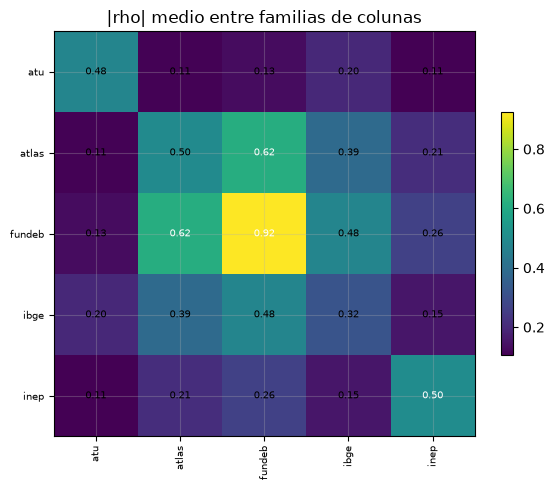

In [22]:
# Correlação média entre famílias (bloco a bloco)
blocos = pd.DataFrame(index=list(FAMILIAS), columns=list(FAMILIAS), dtype=float)
for f1 in FAMILIAS:
    for f2 in FAMILIAS:
        sub = corr.loc[FAMILIAS[f1], FAMILIAS[f2]].abs()
        if f1 == f2:
            sub = sub.where(np.triu(np.ones(sub.shape), k=1).astype(bool))
        blocos.loc[f1, f2] = sub.stack().mean()
blocos = blocos.astype(float)

fig, ax = plt.subplots(figsize=(6, 5))
heatmap(blocos, ax=ax, annot=True, fmt=".2f", cmap="viridis",
        xticklabels=list(blocos.columns), yticklabels=list(blocos.index))
ax.set_title("|rho| medio entre familias de colunas")
plt.tight_layout()
plt.show()

## 7. Relação com o alvo

Para cada coluna `ctx_*` comparamos a média entre alunos alfabetizados (1) e
não alfabetizados (0), padronizada (diferença em desvios-padrão) para dar pra
comparar indicadores em escalas diferentes. Também a correlação ponto-bisserial
(Spearman da coluna com o alvo binário).

⚠️ **Interpretação:** isto é feito em nível de aluno, mas as colunas `ctx_*` são
do município. Uma associação forte aqui diz que *alunos de municípios com tal
característica tendem a se alfabetizar mais/menos* — é padrão regional, não
efeito individual e não é causal. Serve para priorizar hipóteses e features.

In [23]:
# amostra p/ velocidade (5.3M linhas x ~70 colunas em groupby+corr é pesado)
amostra = df.sample(n=min(600_000, len(df)), random_state=42)

g = amostra.groupby(ALVO)[CTX_COLS].mean().T
g.columns = ["media_nao_alfab", "media_alfab"]
desv = amostra[CTX_COLS].std()
g["dif_padronizada"] = (g["media_alfab"] - g["media_nao_alfab"]) / desv
g["rho_alvo"] = amostra[CTX_COLS].corrwith(amostra[ALVO], method="spearman")
g["familia"] = [next(f for f, cols in FAMILIAS.items() if c in cols) for c in g.index]

ranking = g.reindex(g["dif_padronizada"].abs().sort_values(ascending=False).index)
print("Top 20 colunas por |diferença padronizada| vs alvo:\n")
print(ranking.head(20)[["media_nao_alfab", "media_alfab", "dif_padronizada", "rho_alvo", "familia"]].round(3))

Top 20 colunas por |diferença padronizada| vs alvo:

                                             media_nao_alfab  media_alfab dif_padronizada  rho_alvo familia
ctx_inep_mun_taxa_alfabetizacao_lag1                51.98246    59.949507        0.497887     0.234    inep
ctx_inep_mun_media_portugues_lag1                 739.775776   749.545692        0.486381     0.237    inep
ctx_inep_mun_nivel_alfabetizacao_lag1                 1.7463     2.464954        0.480739     0.229    inep
ctx_inep_mun_meta                                  56.876422    62.387863        0.429732     0.217    inep
ctx_inep_uf_taxa_alfabetizacao_lag1                54.999957     59.48443        0.395147     0.181    inep
ctx_inep_uf_media_portugues_lag1                  743.407562   748.975456        0.381355     0.193    inep
ctx_inep_uf_meta                                   60.095393    63.153265        0.378264     0.170    inep
ctx_inep_mun_percentual_participacao_lag1          86.392052     88.24731        0.

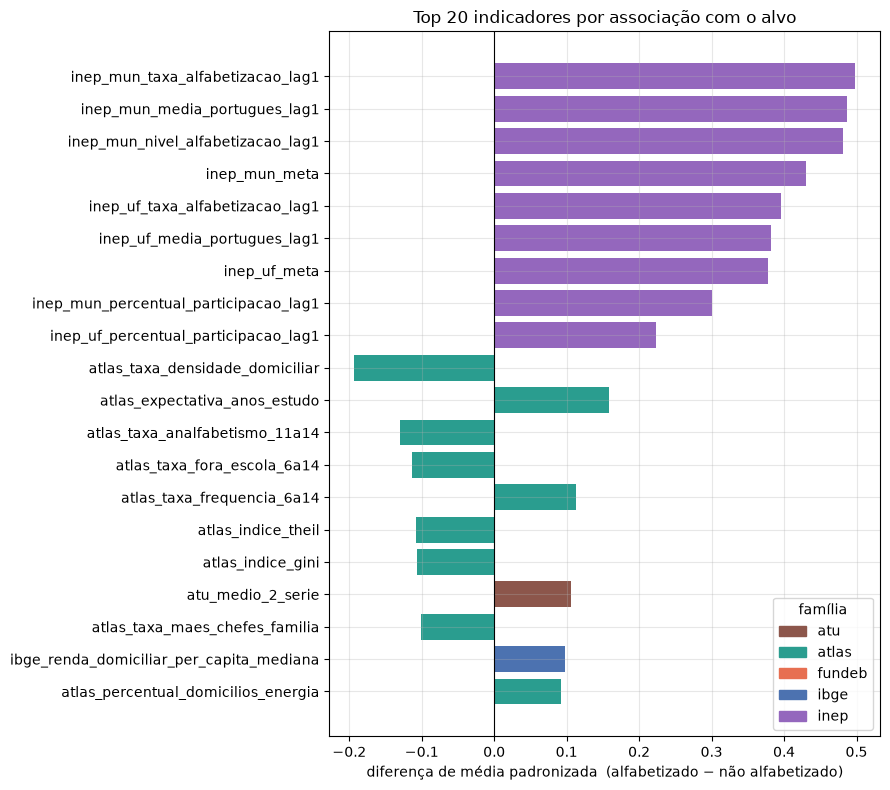

In [24]:
top = ranking.head(20).iloc[::-1]
cores_fam = {"atu": "#8c564b", "atlas": "#2a9d8f", "fundeb": "#e76f51",
             "ibge": "#4c72b0", "inep": "#9467bd"}

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh([c.split("ctx_")[-1] for c in top.index], top["dif_padronizada"],
        color=[cores_fam[f] for f in top["familia"]])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("diferença de média padronizada  (alfabetizado − não alfabetizado)")
ax.set_title("Top 20 indicadores por associação com o alvo")
handles = [plt.Rectangle((0, 0), 1, 1, color=v) for v in cores_fam.values()]
ax.legend(handles, cores_fam.keys(), title="família", loc="lower right")
plt.tight_layout()
plt.show()

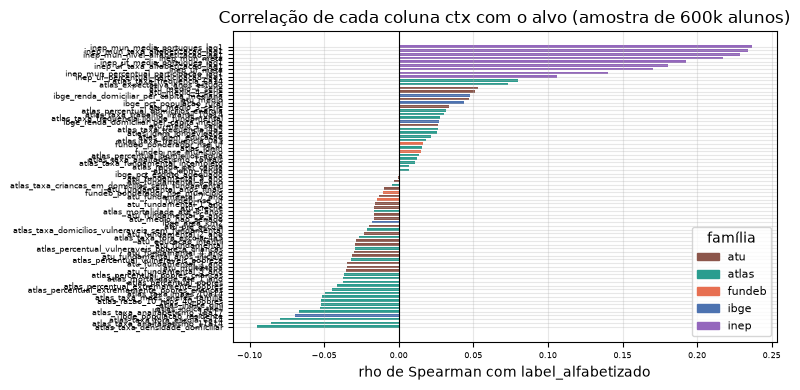

|rho| médio com o alvo por família:
familia
inep      0.190
atlas     0.038
ibge      0.034
atu       0.026
fundeb    0.014
Name: rho_alvo, dtype: float64


In [25]:
# |rho| com o alvo por família — qual fonte carrega mais sinal marginal
fig, ax = plt.subplots(figsize=(8, 4))
g_sorted = g.sort_values("rho_alvo")
ax.barh([c.split("ctx_")[-1] for c in g_sorted.index], g_sorted["rho_alvo"],
        color=[cores_fam[f] for f in g_sorted["familia"]], height=0.7)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("rho de Spearman com label_alfabetizado")
ax.set_title("Correlação de cada coluna ctx com o alvo (amostra de 600k alunos)")
ax.tick_params(labelsize=6)
handles = [plt.Rectangle((0, 0), 1, 1, color=v) for v in cores_fam.values()]
ax.legend(handles, cores_fam.keys(), title="família", loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

print("|rho| médio com o alvo por família:")
print(g.groupby("familia")["rho_alvo"].agg(lambda s: s.abs().mean()).sort_values(ascending=False).round(3))

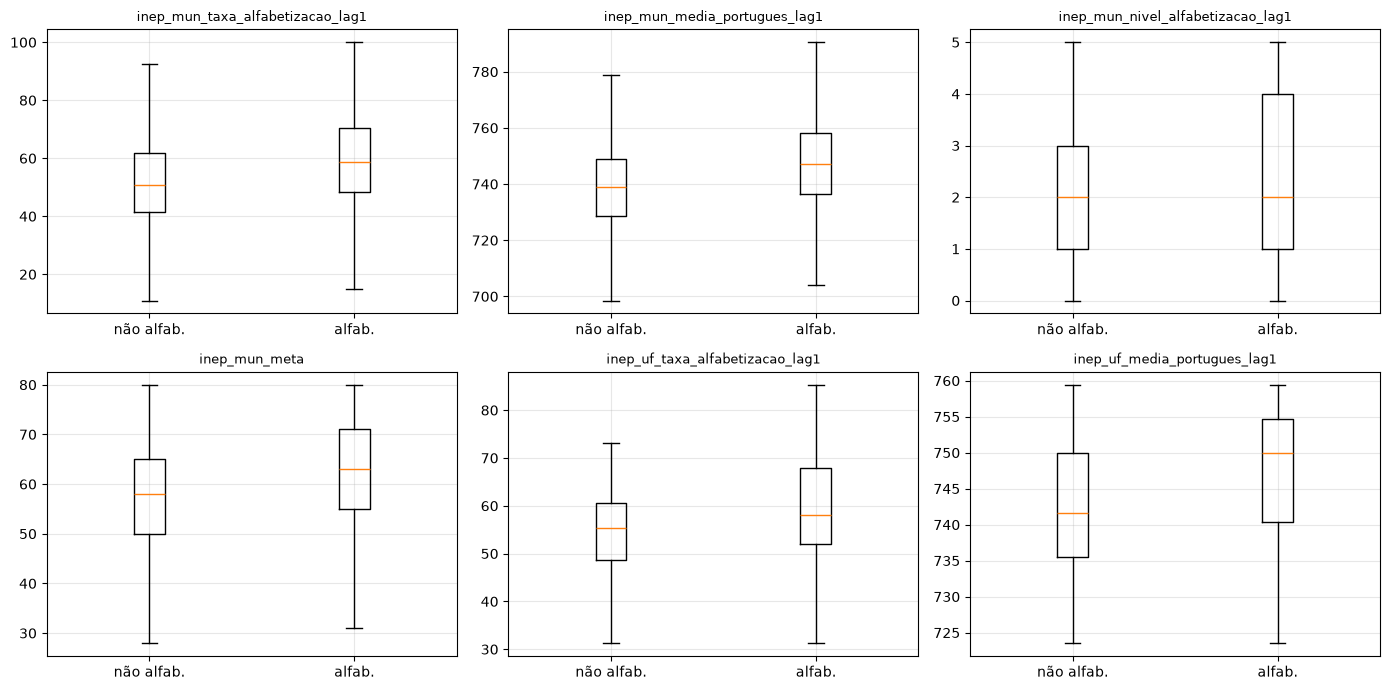

In [26]:
# Boxplots dos indicadores mais associados, por classe do alvo
destaque = ranking.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, destaque):
    data = [amostra.loc[amostra[ALVO] == k, col].dropna() for k in (0, 1)]
    ax.boxplot(data, tick_labels=["não alfab.", "alfab."], showfliers=False)
    ax.set_title(col.split("ctx_")[-1], fontsize=9)
plt.tight_layout()
plt.show()

## 8. Padrões geográficos

Recorte por região e por UF: taxa de alfabetização observada e como ela anda
junto com os indicadores de contexto. Primeiro olhar descritivo — uma
clusterização formal ("quais regiões têm padrões parecidos?") fica como próximo
passo se o time achar útil.

In [27]:
UF_INFO = {
    11: ("RO", "Norte"), 12: ("AC", "Norte"), 13: ("AM", "Norte"), 14: ("RR", "Norte"),
    15: ("PA", "Norte"), 16: ("AP", "Norte"), 17: ("TO", "Norte"),
    21: ("MA", "Nordeste"), 22: ("PI", "Nordeste"), 23: ("CE", "Nordeste"),
    24: ("RN", "Nordeste"), 25: ("PB", "Nordeste"), 26: ("PE", "Nordeste"),
    27: ("AL", "Nordeste"), 28: ("SE", "Nordeste"), 29: ("BA", "Nordeste"),
    31: ("MG", "Sudeste"), 32: ("ES", "Sudeste"), 33: ("RJ", "Sudeste"), 35: ("SP", "Sudeste"),
    41: ("PR", "Sul"), 42: ("SC", "Sul"), 43: ("RS", "Sul"),
    50: ("MS", "Centro-Oeste"), 51: ("MT", "Centro-Oeste"),
    52: ("GO", "Centro-Oeste"), 53: ("DF", "Centro-Oeste"),
}
df["uf_sigla"] = df["id_uf"].map(lambda x: UF_INFO.get(x, ("??", "??"))[0])
df["regiao"] = df["id_uf"].map(lambda x: UF_INFO.get(x, ("??", "??"))[1])

              taxa_alfab  n_alunos   idhm  pct_pobres  nse_municipio  inep_taxa_lag1
regiao                                                                              
Norte              0.545    579757  0.654      29.113         43.846          49.268
Nordeste           0.595   1471400  0.641      32.259         42.829          55.301
Sudeste            0.629   1875806  0.751       7.616         54.921          56.439
Sul                0.654    879301  0.747       5.778         58.493          63.646
Centro-Oeste       0.663    514468  0.731       8.816         51.753          62.155


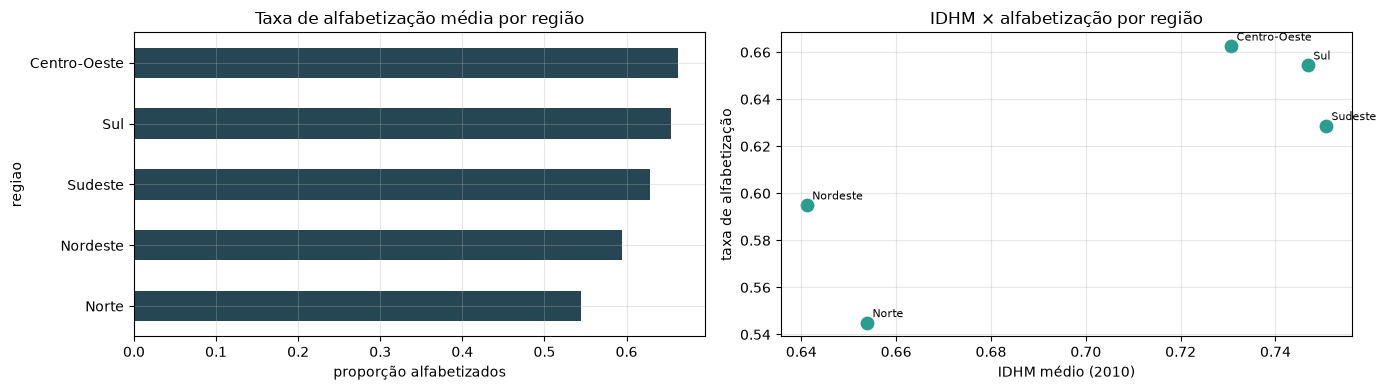

In [28]:
reg = df.groupby("regiao").agg(
    taxa_alfab=(ALVO, "mean"),
    n_alunos=(ALVO, "size"),
    idhm=("ctx_atlas_idhm", "mean"),
    pct_pobres=("ctx_atlas_percentual_pobres", "mean"),
    nse_municipio=("ctx_fundeb_nse_municipio", "mean"),
    inep_taxa_lag1=("ctx_inep_mun_taxa_alfabetizacao_lag1", "mean"),
).sort_values("taxa_alfab")
print(reg.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
reg["taxa_alfab"].plot(kind="barh", ax=axes[0], color="#264653")
axes[0].set_title("Taxa de alfabetização média por região")
axes[0].set_xlabel("proporção alfabetizados")

axes[1].scatter(reg["idhm"], reg["taxa_alfab"], s=80, color="#2a9d8f")
for r in reg.index:
    axes[1].annotate(r, (reg.loc[r, "idhm"], reg.loc[r, "taxa_alfab"]),
                     fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[1].set_xlabel("IDHM médio (2010)")
axes[1].set_ylabel("taxa de alfabetização")
axes[1].set_title("IDHM × alfabetização por região")
plt.tight_layout()
plt.show()

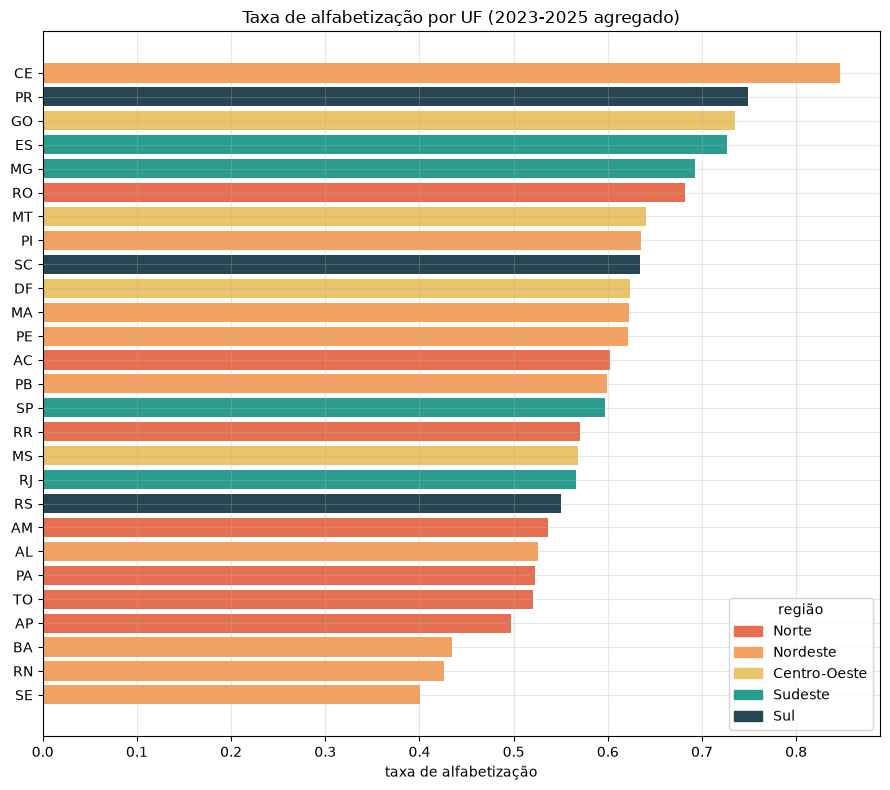

In [29]:
uf = df.groupby(["uf_sigla", "regiao"]).agg(
    taxa_alfab=(ALVO, "mean"), n_alunos=(ALVO, "size"),
    idhm=("ctx_atlas_idhm", "mean"),
).reset_index().sort_values("taxa_alfab")

fig, ax = plt.subplots(figsize=(9, 8))
paleta = {"Norte": "#e76f51", "Nordeste": "#f4a261", "Centro-Oeste": "#e9c46a",
          "Sudeste": "#2a9d8f", "Sul": "#264653"}
ax.barh(uf["uf_sigla"], uf["taxa_alfab"], color=[paleta[r] for r in uf["regiao"]])
ax.set_xlabel("taxa de alfabetização")
ax.set_title("Taxa de alfabetização por UF (2023-2025 agregado)")
handles = [plt.Rectangle((0, 0), 1, 1, color=v) for v in paleta.values()]
ax.legend(handles, paleta.keys(), title="região")
plt.tight_layout()
plt.show()

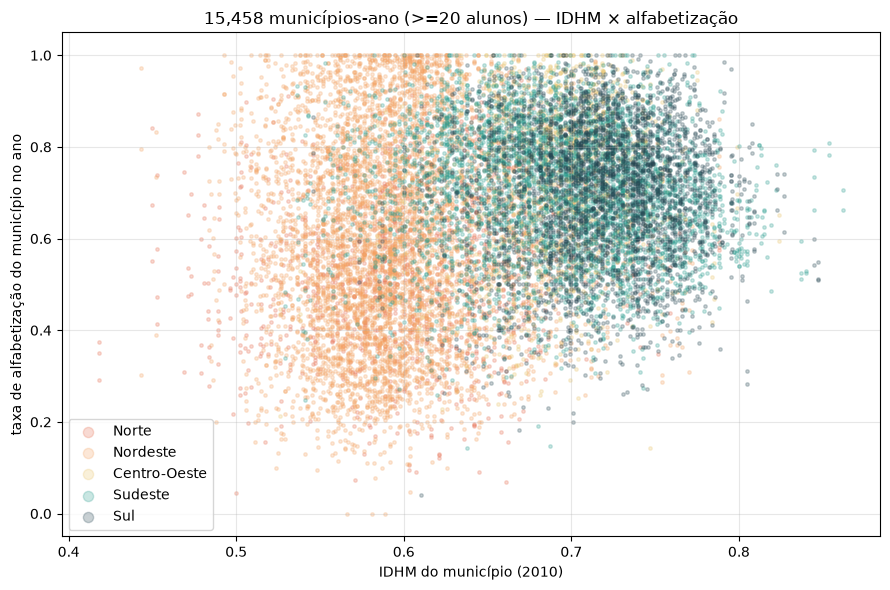

Spearman IDHM x taxa_alfab (município-ano): 0.208


In [30]:
# Dispersão município-ano: IDHM vs taxa de alfabetização do município no ano
mun_alfab = df.groupby(["id_municipio", "ano"]).agg(
    taxa_alfab=(ALVO, "mean"), n_alunos=(ALVO, "size"),
    idhm=("ctx_atlas_idhm", "first"), regiao=("regiao", "first"),
).reset_index()
mun_alfab = mun_alfab[mun_alfab["n_alunos"] >= 20]  # evita ruído de municípios minúsculos

fig, ax = plt.subplots(figsize=(9, 6))
for r, cor in paleta.items():
    s = mun_alfab[mun_alfab["regiao"] == r]
    ax.scatter(s["idhm"], s["taxa_alfab"], s=6, alpha=0.25, color=cor, label=r)
ax.set_xlabel("IDHM do município (2010)")
ax.set_ylabel("taxa de alfabetização do município no ano")
ax.set_title(f"{len(mun_alfab):,} municípios-ano (>=20 alunos) — IDHM × alfabetização")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

print("Spearman IDHM x taxa_alfab (município-ano):",
      round(mun_alfab["idhm"].corr(mun_alfab["taxa_alfab"], method="spearman"), 3))

## 9. Evolução temporal (2023 → 2025)

A base tem três edições. O que muda entre elas — só a taxa do alvo, ou também a
cobertura e o nível dos indicadores de contexto?

In [31]:
temporal = df.groupby("ano").agg(
    n_alunos=(ALVO, "size"),
    taxa_alfab=(ALVO, "mean"),
    cobertura_fundeb=("ctx_fundeb_nse_municipio", lambda s: s.notna().mean()),
    cobertura_inep_lag1=("ctx_inep_mun_taxa_alfabetizacao_lag1", lambda s: s.notna().mean()),
    cobertura_ibge_pop=("ctx_ibge_populacao_residente", lambda s: s.notna().mean()),
    idhm_medio=("ctx_atlas_idhm", "mean"),
    nse_mun_medio=("ctx_fundeb_nse_municipio", "mean"),
    inep_taxa_lag1_media=("ctx_inep_mun_taxa_alfabetizacao_lag1", "mean"),
).round(3)
print(temporal.T)

ano                      2023     2024     2025
n_alunos              1502809  1851828  1966095
taxa_alfab              0.584    0.598    0.663
cobertura_fundeb          0.0    0.988    0.988
cobertura_inep_lag1       0.0     0.98    0.979
cobertura_ibge_pop        0.0      1.0      1.0
idhm_medio              0.694    0.713    0.711
nse_mun_medio             NaN   51.149   50.731
inep_taxa_lag1_media      NaN   55.685   58.244


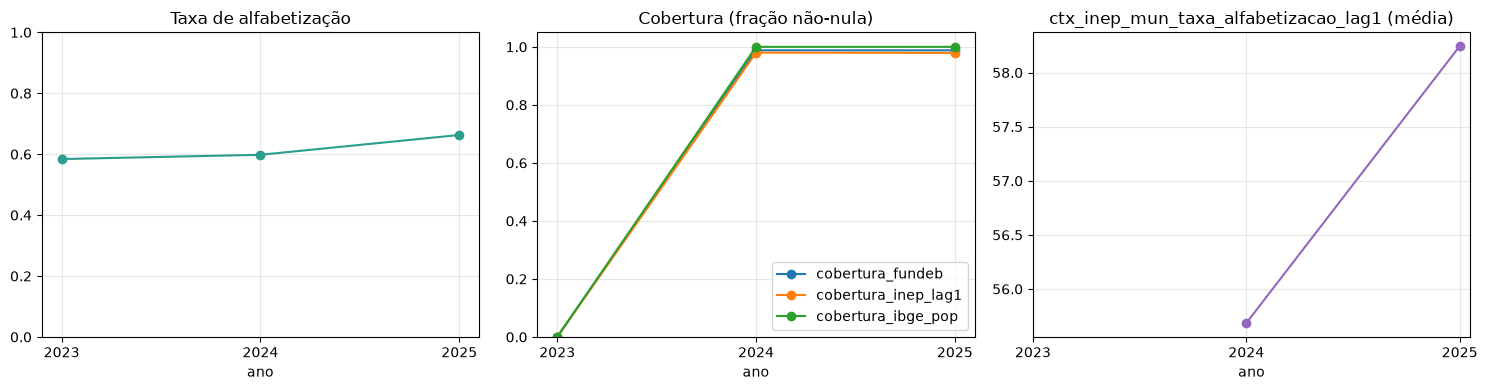

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
temporal["taxa_alfab"].plot(marker="o", ax=axes[0], color="#2a9d8f")
axes[0].set_title("Taxa de alfabetização")
axes[0].set_ylim(0, 1)

temporal[["cobertura_fundeb", "cobertura_inep_lag1", "cobertura_ibge_pop"]].plot(
    marker="o", ax=axes[1])
axes[1].set_title("Cobertura (fração não-nula)")
axes[1].set_ylim(0, 1.05)

temporal["inep_taxa_lag1_media"].plot(marker="o", ax=axes[2], color="#9467bd")
axes[2].set_title("ctx_inep_mun_taxa_alfabetizacao_lag1 (média)")
for ax in axes:
    ax.set_xticks(temporal.index)
plt.tight_layout()
plt.show()

## 10. Resumo dos achados

*(preenchido a partir da execução com os dados reais — 5.320.732 linhas,
84 colunas / 76 delas `ctx_*`, edições 2023-2025)*

**Grão e integridade**
- Grão confirmado: 1 linha por `id_aluno` × `ano`, **0 duplicatas**.
- 2.826.311 alunos distintos; **1.793.730 (63,5%)** aparecem em mais de uma
  edição — atenção ao montar validação: um split aleatório vaza o mesmo aluno
  entre treino e teste. Sugestão: split por `id_aluno` ou por `ano`.
- Nenhuma coluna de vazamento (`proficiencia`, `gap`, `caderno`) sobreviveu ao
  join; as 7 colunas de resultado do INEP estão todas com sufixo `_lag1`, e só
  `ctx_inep_mun_meta` / `ctx_inep_uf_meta` entram sem defasagem (o INEP publica
  a meta antes da prova).
- Só duas redes na base: **Municipal 4.704.938 alunos (88,4%)** e
  **Estadual 615.794 (11,6%)** — sem rede federal nem privada.

**Alvo**
- Taxa de alfabetização da base inteira: **61,8%** (3.287.215 positivos /
  2.033.517 negativos, 0 nulos).
- Sobe a cada ano: **58,4% (2023) → 59,8% (2024) → 66,3% (2025)**. O pulo
  2024→2025 é de +6,5 p.p. contra +1,4 p.p. no ano anterior — **registrar no
  relatório**: pode ser melhora real, mudança de instrumento/critério ou de
  composição de escolas; não tratar as 3 edições como diretamente comparáveis
  sem checar com quem cuida da fonte INEP.
- Por rede (agregado): Estadual **63,1%** vs Municipal **61,6%** — diferença
  pequena (~1,5 p.p.), não um fator forte.
- Classes moderadamente desbalanceadas (~38/62) — não exige reamostragem
  agressiva, mas usar métricas além de acurácia.

**Valores faltantes (todos esperados, documentados)**
- `ctx_atlas_*`: **0,04% nulo** em todo ano — os 6 municípios criados após o
  Censo 2010, ausência de origem (não é falha de join).
- `ctx_fundeb_*`: **100% nulo em 2023** (NSE só publicado a partir de 2024,
  sem proxy — `join.py`); ~0,6% em 2024-2025. ~29% nulo na base inteira.
- `ctx_ibge_populacao_residente` (e `ctx_fundeb_nse_uf`): nulo em 2023 (fonte
  não cobre o ano); as demais colunas IBGE ficam completas.
- `ctx_inep_*_lag1`: **29-31% nulo**, todo concentrado em 2023 (a defasagem
  puxa de 2022, que tem menos municípios avaliados). Em 2024-2025 a cobertura
  é ~98%.
- `ctx_atu_medio_*`: **83-96% nulo** em toda a base — esperado (alfabetização
  é 2º ano do fundamental; a razão aluno/turma do médio não se aplica).
  `ctx_atu_multietapa` ~35%, `anos_finais` / 6º-9º ano ~17%, pela mesma lógica.

**Redundância entre colunas (seção 6) — 100 pares com |ρ| ≥ 0,90**
- Pares praticamente idênticos (|ρ| ≥ 0,99), candidatos diretos a poda:
  `atlas_taxa_frequencia_4a5` × `atlas_taxa_fora_escola_4a5` (ρ = 1,00),
  `atlas_taxa_frequencia_6a14` × `atlas_taxa_fora_escola_6a14` (1,00),
  `atlas_idhm_renda` × `atlas_renda_per_capita` (1,00),
  `fundeb_nse_municipio` × `fundeb_ponderador_nse_municipio` (0,997),
  `atlas_mortalidade_ate_1_ano` × `ate_5_anos` (0,994).
- Blocos colineares maiores: a cadeia de pobreza do Atlas
  (`pobres` ⊇ `extremamente_pobres` ⊇ `vulneraveis`, + versões "crianças"),
  os índices de desigualdade (`gini` × `theil` × `razao_10_ricos_40_pobres`),
  e `atlas_idhm` × `taxa_domicilios_vulneraveis_sem_fundamental` (0,967).
- Entre famílias: `ibge_renda_*_media/mediana` (ρ = 0,979 entre si) puxa junto
  com `atlas_renda_per_capita` e o NSE do FUNDEB — as três fontes medem o
  mesmo eixo "renda do município".
- `inep_mun_taxa_alfabetizacao_lag1` × `inep_mun_nivel_alfabetizacao_lag1`
  (0,985) — a versão categórica é redundante com a contínua.
- Recomendação p/ modelagem: manter um representante por bloco colinear, ou
  usar regularização L1 / seleção por importância — não jogar as 76 colunas
  cruas numa regressão linear.

**Associação com o alvo (seção 7 — amostra de 600k alunos)**
- O sinal marginal está **concentrado na família `ctx_inep_*_lag1`**:
  |ρ| médio com o alvo = **0,19**, contra 0,04 (atlas), 0,03 (ibge),
  0,03 (atu) e **0,01 (fundeb)** — o NSE do FUNDEB é o de menor sinal marginal.
- As 9 primeiras posições do ranking são todas `ctx_inep_*_lag1` (taxa, média
  de português, nível, meta — município e UF), com diferença padronizada
  0,22–0,50 e ρ 0,10–0,24. É persistência regional: municípios que
  alfabetizaram bem no ano anterior seguem melhor.
- Fora do INEP, as associações caem para |ρ| ≤ 0,10 e as maiores são:
  `atlas_taxa_densidade_domiciliar` (−), `atlas_expectativa_anos_estudo` (+),
  `atlas_taxa_analfabetismo_11a14` (−), `atlas_taxa_fora_escola_6a14` (−),
  índices `theil`/`gini` (−), `atu_medio_2_serie` (+, provavelmente espúrio),
  `ibge_renda_domiciliar_per_capita_mediana` (+) e
  `atlas_percentual_domicilios_energia` (+). **O IDHM em si não entra no
  top 20** — o eixo socioeconômico aparece, mas fraco e diluído entre proxies.
- `ctx_atu_*` (razão aluno/turma): associação fraca — turma cheia não separa
  alfabetizado de não alfabetizado neste recorte.
- ⚠️ Tudo isso é contexto municipal compartilhado por todos os alunos do
  município: são padrões regionais, não efeitos individuais nem causais.

**Geografia (seção 8)**
- Gradiente crescente: **Norte 54,5% → Nordeste 59,5% → Sudeste 62,9% →
  Sul 65,4% → Centro-Oeste 66,3%**. O Sudeste tem o maior IDHM médio (0,75)
  mas não a maior alfabetização — a ordem não é a do IDHM.
- Correlação IDHM × taxa de alfabetização em nível **município-ano é positiva
  mas fraca (ρ ≈ 0,21)**. O contexto socioeconômico municipal sozinho explica
  pouco da variação de alfabetização entre municípios.
- Dispersão grande dentro de cada faixa de IDHM — há municípios de IDHM baixo
  com alfabetização alta e vice-versa; espaço real para o modelo agregar valor
  além do puramente socioeconômico (provavelmente via o histórico `_lag1`).

**Limitações**
- Atlas fixo em 2010: 13-15 anos de defasagem em relação aos dados de aluno —
  contexto estrutural, não medida contemporânea.
- FUNDEB sem NSE em 2023 → família inteira ausente nesse ano; e é a família de
  menor sinal marginal quando presente.
- Salto de 2025 no alvo não explicado só pelos dados.
- Contexto no grão municipal (ou UF): teto de granularidade — variação
  intra-município (entre escolas, entre alunos) não é observável nas features
  atuais, e o `dependencia_administrativa` é o único atributo do aluno/escola.

## Próximos passos sugeridos

1. **Estratégia de validação** que respeite `id_aluno` e/ou `ano` (evitar
   vazamento pelo aluno repetido entre edições).
2. **Poda de colunas colineares** antes da modelagem linear, ou partir para
   modelo baseado em árvore + importância de permutação.
3. Transformar a ausência de NSE em 2023 numa **feature binária explícita**
   (`tem_nse`) em vez de só `NaN`.
4. Repetir a seção 7 **controlando por UF/região** para separar efeito de
   nível de desenvolvimento de efeito puramente geográfico.
5. Investigar o **salto de 2025** com quem cuida da fonte INEP antes de tratar
   as três edições como comparáveis.
6. Avaliar **clusterização de municípios** pelas colunas `ctx_*` para a
   pergunta "quais regiões têm padrões semelhantes?".
7. Dado que o sinal está quase todo em `ctx_inep_*_lag1`, medir **quanto as
   outras quatro famílias agregam** sobre um baseline só com o histórico
   defasado (ablação por família), para decidir o que vale manter no pipeline.